# 03 — ABC Analysis, Pick Frequency & Slotting

**Questions:** Which products move fastest? Where should each one sit? And how often should each one be counted?

Notebook 2 worked out how much space the stock needs. This notebook decides **where** it goes — using four months of order history.

Two different ABC classifications, because they answer different questions:

| Classification | Ranks SKUs by | Used for |
|---|---|---|
| **Velocity ABC** | Order lines (how often it's picked) | Slotting — fast movers go where picking is quickest |
| **Value ABC** | Sales value | Inventory control — high-value stock gets counted most often |

The split is the classic Pareto cut: **A** = first 80% of the total, **B** = next 15%, **C** = last 5%. **D** = no orders at all in the period.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA, OUT = Path("../data"), Path("../outputs")

orders = pd.read_csv(DATA / "order_lines.csv", parse_dates=["order_date"])
pallet = pd.read_csv(DATA / "pallet_build.csv")
stock = pd.read_csv(DATA / "storage_requirement.csv")

PICK_DAYS = orders.order_date.nunique()
MONTHS = 4
print(f"{len(orders):,} order lines over {PICK_DAYS} picking days")

52,000 order lines over 85 picking days


## 1. Demand profile per SKU

For every SKU over the four months: how many order lines, how many units, and what sales value. SKUs that never appear in the orders stay in the table with zero demand — they matter, because they're taking up space.

In [ ]:
demand = orders.groupby("sku").agg(lines=("sku", "size"), units=("qty_units", "sum"))

sku = pallet.set_index("sku")[["description", "principal", "product_group", "storage_condition",
                              "units_per_case", "cases_per_pallet", "unit_cost_nzd"]].join(demand).fillna({"lines": 0, "units": 0})
sku["sales_value_nzd"] = sku.units * sku.unit_cost_nzd
sku[["lines", "units", "sales_value_nzd"]].describe().round(0)

,lines,units,sales_value_nzd
count,588.0,588.0,588.0
mean,87.0,6187.0,90184.0
std,155.0,12442.0,192127.0
min,0.0,0.0,0.0
25%,9.0,494.0,4483.0
50%,32.0,1932.0,21489.0
75%,85.0,5395.0,78682.0
max,1179.0,129778.0,1453725.0


## 2. ABC classification

Sort SKUs from highest to lowest, calculate each one's running share of the total, and cut at 80% and 95%.

In [ ]:
def abc(series):
    # Ties broken by SKU code, so the result is identical on every machine
    ranked = series.sort_index().sort_values(ascending=False, kind="stable")
    cum_share = ranked.cumsum() / ranked.sum()
    cls = pd.Series(np.select([cum_share <= 0.80, cum_share <= 0.95], ["A", "B"], "C"), index=ranked.index)
    return cls.reindex(series.index).where(series > 0, "D")

sku["abc_velocity"] = abc(sku.lines)
sku["abc_value"] = abc(sku.sales_value_nzd)

summary = pd.DataFrame({
    "SKUs (velocity)": sku.abc_velocity.value_counts(),
    "share of lines": sku.groupby("abc_velocity").lines.sum() / sku.lines.sum(),
    "SKUs (value)": sku.abc_value.value_counts(),
    "share of value": sku.groupby("abc_value").sales_value_nzd.sum() / sku.sales_value_nzd.sum(),
}).sort_index()
summary.round(3)

,SKUs (velocity),share of lines,SKUs (value),share of value
A,160,0.799,121,0.799
B,163,0.151,146,0.151
C,247,0.050,303,0.050
D,18,0.000,18,0.000


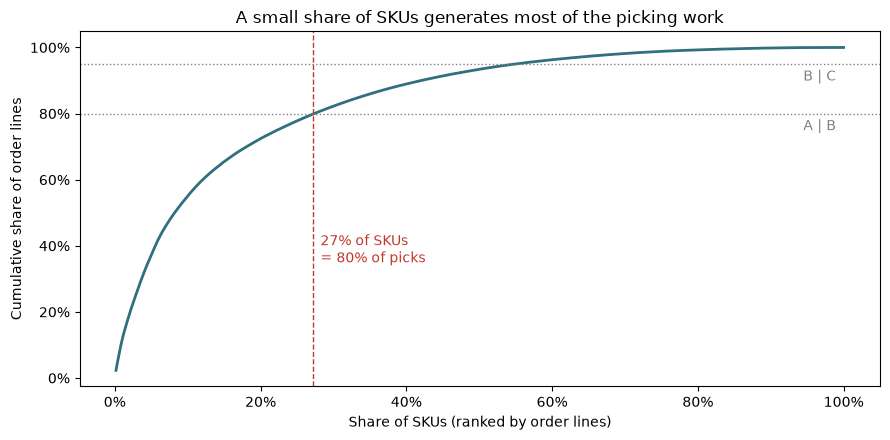

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ranked = sku.lines.sort_values(ascending=False)
x = np.arange(1, len(ranked) + 1) / len(ranked)
y = ranked.cumsum() / ranked.sum()
ax.plot(x, y, color="#2f6f7e", lw=2)
for cut, label in [(0.80, "A | B"), (0.95, "B | C")]:
    ax.axhline(cut, color="grey", ls=":", lw=1)
    ax.text(0.99, cut - 0.05, label, ha="right", color="grey")
a_share = (sku.abc_velocity == "A").sum() / len(sku)
ax.axvline(a_share, color="#c0392b", ls="--", lw=1)
ax.text(a_share + 0.01, 0.35, f"{a_share:.0%} of SKUs\n= 80% of picks", color="#c0392b")
ax.set(title="A small share of SKUs generates most of the picking work",
       xlabel="Share of SKUs (ranked by order lines)", ylabel="Cumulative share of order lines")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.savefig(OUT / "03_pareto_order_lines.png", dpi=150)
plt.show()

## 3. Velocity and value are not the same thing

A cheap product can be picked constantly. An expensive one can barely move. Cross-tabulating the two shows why a single ABC isn't enough:

In [ ]:
pd.crosstab(sku.abc_velocity, sku.abc_value, margins=True, margins_name="Total")

abc_value,A,B,C,D,Total
abc_velocity,,,,,
A,100,41,19,0,160
B,18,79,66,0,163
C,3,26,218,0,247
D,0,0,0,18,18
Total,121,146,303,18,588


In [ ]:
# Fast-moving but low-value, and slow-moving but high-value
cols = ["description", "product_group", "lines", "sales_value_nzd"]
print("Picked constantly, low value:")
display(sku[(sku.abc_velocity == "A") & (sku.abc_value == "C")].sort_values("lines", ascending=False)[cols].head(5))
print("Rarely picked, high value:")
display(sku[(sku.abc_velocity == "C") & (sku.abc_value == "A")][cols])

Picked constantly, low value:


,description,product_group,lines,sales_value_nzd
sku,,,,
SG20021,Crepe Bandage 10cm x100,Surgical,792.0,21553.70
SG20041,Nitrile Examination Gloves Size M x100,Surgical,627.0,21260.16
PH10381,Dextrose 5% IV 500ml Bag,IV Fluids,174.0,13946.10
SG20034,IV Cannula 20G x50,Surgical,152.0,24716.16
PH10376,Sodium Chloride 0.9% IV 1000ml Bottle,IV Fluids,146.0,23113.16


Rarely picked, high value:


,description,product_group,lines,sales_value_nzd
sku,,,,
SG20053,TSH Reagent Kit 25 Tests,Diagnostics,14.0,141731.52
SG20054,Pregnancy Test Strips 25 Tests,Diagnostics,21.0,100714.24
SG20056,Urine Test Strips 10-Parameter 25 Tests,Diagnostics,22.0,130429.60


## 4. Pick frequency and replenishment

For slotting, what matters is how often each SKU is touched per day, and how fast it empties a pallet:

- **Lines per day** — how many times a picker visits the location
- **Pallets per week** — how many times the pick face needs refilling from reserve

In [ ]:
sku["lines_per_day"] = sku.lines / PICK_DAYS
sku["cases_per_day"] = sku.units / sku.units_per_case / PICK_DAYS
sku["pallets_per_week"] = sku.cases_per_day * 5 / sku.cases_per_pallet

sku.groupby("abc_velocity")[["lines_per_day", "pallets_per_week"]].agg(["median", "max"]).round(2)

lines_per_day        pallets_per_week       
                    median    max           median    max
abc_velocity                                             
A                     1.85  13.87             0.32  19.33
B                     0.53   0.92             0.08   1.15
C                     0.11   0.29             0.01   0.48
D                     0.00   0.00             0.00   0.00

## 5. Slotting rules

| Velocity | Pick location | Why |
|---|---|---|
| **A** | Dedicated **ground-level pallet pick face** | Picked most days — must be reachable by hand without a forklift |
| **A**, emptying more than 1 pallet a day | **Two** ground-level pick faces | One pallet empties before replenishment can keep up |
| **B** | **Shelving pick bin** | Picked a few times a week — a bin holds enough, and saves ground positions |
| **C** | Picked **direct from reserve** | Picked rarely — a forklift retrieval is acceptable |
| **D** | **No pick face** — review with client | No orders in four months |

The A-class ground pick face is one of the SKU's own pallet positions, so it adds no extra positions — it only decides which level the pallet sits on. B-class pick bins **are** extra: they're shelving locations on top of reserve storage.

In [ ]:
sku["pick_location"] = np.select(
    [sku.abc_velocity == "A", sku.abc_velocity == "B", sku.abc_velocity == "C"],
    ["Ground pick face", "Shelving pick bin", "Direct from reserve"], default="No pick face")
sku["ground_faces"] = np.where(sku.abc_velocity == "A", np.where(sku.pallets_per_week > 5, 2, 1), 0)
sku["pick_bins"] = (sku.abc_velocity == "B").astype(int)

slot = sku.groupby("storage_condition").agg(
    A_SKUs=("abc_velocity", lambda s: (s == "A").sum()),
    ground_pick_faces=("ground_faces", "sum"),
    shelving_pick_bins=("pick_bins", "sum"))
slot

,A_SKUs,ground_pick_faces,shelving_pick_bins
storage_condition,,,
2-8C,5,5,15
Ambient,13,16,17
Below 25C,142,142,131


### Does it fit Chamber A?

Chamber A has 190 bays, each two pallets wide, across 5 beam levels — 1,900 positions, of which **380 are at ground level**. Ground-level pick faces must fit within those 380.

In [ ]:
GROUND_POSITIONS_A = 380
faces = slot.loc["Below 25C", "ground_pick_faces"]
bins_small_batches = stock[(stock.storage_condition == "Below 25C") & (stock.zone == "Shelving")].shape[0]
bins_pick = slot.loc["Below 25C", "shelving_pick_bins"]

print(f"Ground pick faces needed: {faces} of {GROUND_POSITIONS_A} ground positions ({faces/GROUND_POSITIONS_A:.0%})")
print(f"Shelving bins needed in Chamber A: {bins_small_batches} small batches + {bins_pick} B pick bins = {bins_small_batches + bins_pick}")

Ground pick faces needed: 142 of 380 ground positions (37%)
Shelving bins needed in Chamber A: 448 small batches + 131 B pick bins = 579


## 6. Stock cover

**Months of cover** = saleable stock on hand ÷ average monthly demand. It shows how long current stock would last, and where the client is overstocked.

In [ ]:
on_hand = stock[stock.stock_type.isin(["Saleable", "FOC"])].groupby("sku").agg(
    on_hand_units=("qty_units", "sum"), on_hand_value=("value_nzd", "sum"))
sku = sku.join(on_hand).fillna({"on_hand_units": 0, "on_hand_value": 0})
sku["months_cover"] = np.where(sku.units > 0, sku.on_hand_units / (sku.units / MONTHS), np.inf)

bands = pd.cut(sku.months_cover, [0, 3, 6, 12, 1000, np.inf],
               labels=["Under 3", "3–6", "6–12", "Over 12", "No demand"], include_lowest=True)
cover = sku.groupby(bands, observed=True).agg(SKUs=("description", "size"), stock_value_nzd=("on_hand_value", "sum"))
cover["share_of_value"] = cover.stock_value_nzd / cover.stock_value_nzd.sum()
cover.round(2)

,SKUs,stock_value_nzd,share_of_value
months_cover,,,
Under 3,65,3869446.14,0.05
3–6,215,32310473.97,0.45
6–12,199,25820156.47,0.36
Over 12,91,9665638.16,0.13
No demand,18,94828.21,0.00


## 7. Cycle count programme

A standard frequency by **value** class — high-value stock is counted most often, because an error there costs the most:

| Value class | Frequency | Counts per year |
|---|---|---|
| A | Monthly | 12 |
| B | Quarterly | 4 |
| C | Twice a year | 2 |
| D | Once a year, plus disposal review | 1 |

In [ ]:
FREQ = {"A": 12, "B": 4, "C": 2, "D": 1}
WORKING_WEEKS = 50

sku["counts_per_year"] = sku.abc_value.map(FREQ)
programme = sku.groupby("abc_value").agg(SKUs=("description", "size"), counts_per_year=("counts_per_year", "sum"))
programme.loc["Total"] = programme.sum()
programme["counts_per_week"] = programme.counts_per_year / WORKING_WEEKS
programme.round(1)

,SKUs,counts_per_year,counts_per_week
abc_value,,,
A,121,1452,29.0
B,146,584,11.7
C,303,606,12.1
D,18,18,0.4
Total,588,2660,53.2


## 8. Save

In [ ]:
out_cols = ["description", "principal", "product_group", "storage_condition", "lines", "units",
            "sales_value_nzd", "abc_velocity", "abc_value", "lines_per_day", "pallets_per_week",
            "pick_location", "ground_faces", "pick_bins", "months_cover", "counts_per_year"]
sku[out_cols].to_csv(DATA / "slotting.csv")

with pd.ExcelWriter(OUT / "03_abc_slotting.xlsx") as xl:
    summary.to_excel(xl, sheet_name="ABC summary")
    sku[out_cols].sort_values("lines", ascending=False).to_excel(xl, sheet_name="SKU slotting")
    cover.to_excel(xl, sheet_name="Stock cover")
    programme.to_excel(xl, sheet_name="Cycle count programme")

print("Saved slotting.csv and 03_abc_slotting.xlsx")

Saved slotting.csv and 03_abc_slotting.xlsx


## Findings

- **160 SKUs (27%) generate 80% of all order lines.** These are the products that decide how efficiently the warehouse picks.
- **Velocity and value rank products differently.** 19 SKUs are picked constantly but are low value — bandages, gloves, IV fluids. Three diagnostic kits are rarely picked but high value. Using one ABC for both slotting and counting would put the wrong products in the wrong places.
- **Chamber A slotting fits at ground level:** 142 ground pick faces use 37% of the 380 ground positions.
- **But Chamber A now needs 579 shelving bins** — 448 for small batches and 131 as pick bins for B-class SKUs — and it has none. Notebook 4 has to create them.
- **NZ$9.7M of stock (13% of value) sits across 91 SKUs with more than 12 months' cover**, and 18 SKUs had no orders at all in four months. Both are worth raising with the client before paying to move and store them.
- **The cycle count programme needs about 2,660 SKU counts a year — roughly 53 a week, or 11 per working day.** More than half the effort goes to the 121 A-value SKUs, which is where count accuracy matters most.